# Dispersion-Assisted Optical Phase Recovery — v10 (Publishable)
## ECE 279AS · UCLA · Spring 2026 · Collin

A clean, structured walkthrough of the full pipeline:

1. Physics primer — complex field, intensity, Gerchberg–Saxton, Hilbert / minimum-phase, Kramers–Kronig, dispersion, time stretch
2. Time / grid calculations — `dt`, `df`, `T`, Nyquist, dispersion delay, runtime estimates
3. NumPy baseline — forward model, TD-GS
4. PyTorch GPU port — same algorithm, batched
5. Optional CUDA / cuFFT design notes
6. Experiments — noise sweep, sampling-rate sweep, dispersion sweep, Hilbert-vs-GS, CPU-vs-GPU benchmark
7. Engineering companion — C, Verilog, Makefile, hardware-timing analogy
8. Summary tables + 3 practice problems

Assumptions and units are stated in each section. Numerical sanity checks accompany every algorithm. Each code cell runs in seconds on CPU; the GPU section auto-falls-back to CPU if CUDA isn't available.

In [1]:
# 0. Setup
import time, math, subprocess, os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

try:
    import torch
    HAVE_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
except ImportError:
    HAVE_TORCH, DEVICE = False, None

plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'lines.linewidth': 1.5,
                     'axes.spines.top': False, 'axes.spines.right': False})
rng = np.random.default_rng(7)
print('NumPy', np.__version__, '| PyTorch:', HAVE_TORCH, '| device:', DEVICE)

NumPy 2.3.5 | PyTorch: True | device: cpu


---
## 1. Physics primer

### 1.1 Complex field, amplitude, phase, intensity

A narrowband optical envelope at the carrier frequency is a complex function $E(\omega) = A(\omega)\,e^{j\phi(\omega)}$ with **amplitude** $A(\omega)\ge 0$ and **phase** $\phi(\omega)\in[-\pi,\pi)$. A photodetector reports only **intensity** $I(t) = |e(t)|^2 = e(t)\,e^*(t)$, where $e(t) = \mathcal{F}^{-1}\{E(\omega)\}$. The squaring **destroys phase information** — that's the entire problem.

### 1.2 Group-velocity dispersion (GVD)

Fiber adds a quadratic spectral phase: $H(\omega; \phi_2) = \exp(j\phi_2\omega^2/2)$, where $\phi_2 = \beta_2\,L = -D\,\lambda_0^2/(2\pi c)$ for $D$ in s/m² (engineering units: ps/nm). Convert: at $\lambda_0 = 1550$ nm, $D = 1$ ps/nm gives $\phi_2 \approx -1.275 \times 10^{-24}$ s²/rad.

### 1.3 Time stretch / dispersive Fourier transform

In the far-field $|\phi_2|\,2\pi\Delta f \gg \sigma_t$, the photodetected intensity is approximately a stretched copy of the input spectrum: $I(t)\propto S(t/(2\pi\phi_2))$. This is the *dispersive Fourier transform* — the backbone of fast spectroscopy and the receiver topology we're inverting.

### 1.4 Gerchberg–Saxton

Magnitude-only constraints at two propagation planes give an iterative projection:
1. forward propagate plane 1 → plane 2,
2. replace magnitude at plane 2 with $\sqrt{I_2(t)}$,
3. backward propagate plane 2 → plane 1,
4. replace magnitude at plane 1 with $\sqrt{I_1(t)}$, repeat.

GS 1972 proved the residual is monotone non-increasing; it can stagnate at local minima but cannot diverge. Required diversity: $|D_2|/|D_1|\gtrsim 1.33$ (Solli 2009).

### 1.5 Hilbert / minimum-phase recovery (Kramers–Kronig)

For a *minimum-phase* signal (all spectral zeros in the upper half-plane), magnitude and phase form a Hilbert pair:

$$\phi(\omega) \;=\; -\mathcal{H}\{\ln|E(\omega)|\}.$$

This is a **closed-form, single-FFT** alternative to GS. The catch: most chirped or asymmetric optical signals are not minimum-phase, so KK fails predictably on them. A **KK→GS hybrid** uses KK as a seed and GS to refine — fast convergence + general validity.

### 1.6 Kramers–Kronig and causality

The KK relations are not a phase-retrieval trick; they are a consequence of **causality**. A causal response function has no future-dependence, hence its Fourier transform is analytic in the upper half-plane. By Cauchy's theorem its real and imaginary parts are linked by the Hilbert transform. Same math as the refractive-index ↔ absorption pair $n(\omega) ↔ k(\omega)$ in optics.

---
## 2. Time / grid calculations (state every assumption)

A discrete grid with `N` complex samples and time spacing `dt`:

| Quantity | Formula | This notebook |
|---|---|---|
| Time spacing | `dt` | 0.61 ps |
| Number of samples | `N` | $2^{14} = 16384$ |
| Total time window | `T = N·dt` | 10.0 ns |
| Frequency spacing | `df = 1/T = 1/(N·dt)` | 0.10 GHz |
| Nyquist (one-sided) | `f_Ny = 1/(2·dt)` | 819 GHz |
| Total bandwidth | `B = N·df = 1/dt` | 1638 GHz |
| Dispersion delay across `Δf` | `Δt = 2π·\|φ₂\|·Δf` | 290 ps for `D=−1200 ps/nm`, `Δf=30 GHz` |

**Sampling rule.** For a signal with spectral support $\Delta f$, the dispersive spread $\Delta t_{disp} = 2\pi|\phi_2|\Delta f$ must (i) be much larger than `dt` so dispersion is resolved and (ii) much smaller than `T` so the dispersed pulse doesn't wrap around the periodic FFT array. v10 satisfies both with ~17× headroom on each side.

**Runtime estimates per FFT pair (single waveform, length N):**
- NumPy on a 4-GHz CPU: ~80–150 µs.
- PyTorch CUDA on RTX 4070 class: ~5–10 µs.
- Custom cuFFT plan (batched B=32): same ~5–10 µs *for the whole batch*.

In [2]:
# Constants and grid setup — derive each value, print the assumptions
C_LIGHT, LAMBDA_0 = 2.99792458e8, 1550e-9
GHZ, NS, PS = 1e9, 1e-9, 1e-12

def phi2_from_D(D_ps_per_nm, lam=LAMBDA_0):
    """Convert D[ps/nm] -> phi2[s^2/rad] at carrier wavelength lam."""
    return -(D_ps_per_nm * 1e-12 / 1e-9) * lam**2 / (2*math.pi*C_LIGHT)

N  = 2**14
dt = 0.61 * PS                  # time-domain sample spacing
T  = N * dt                     # total window
df = 1.0 / T                    # = 1/(N·dt)
f_Ny = 1.0/(2*dt)
B_total = 1.0/dt
f_hz  = (np.arange(N) - N//2) * df
w_rad = 2*math.pi*f_hz
t_s   = (np.arange(N) - N//2) * dt
PHI2_1, PHI2_2 = phi2_from_D(-300), phi2_from_D(-1200)

print(f'N         = {N}')
print(f'dt        = {dt/PS:.3f} ps')
print(f'T = N·dt  = {T/NS:.3f} ns')
print(f'df = 1/T  = {df/GHZ:.4f} GHz')
print(f'f_Nyquist = {f_Ny/GHZ:.1f} GHz   (one-sided)')
print(f'B = 1/dt  = {B_total/GHZ:.1f} GHz   (total bandwidth)')
print(f'PHI2_1 (D = -300  ps/nm) = {PHI2_1:+.3e} s²/rad')
print(f'PHI2_2 (D = -1200 ps/nm) = {PHI2_2:+.3e} s²/rad')
print(f'D2/D1 ratio = {abs(PHI2_2/PHI2_1):.2f}  (>>1.33 OK)')
for Df_GHz in [10, 30, 100]:
    spread = abs(PHI2_2) * 2*math.pi * Df_GHz*GHZ / PS
    print(f'  dispersive spread @ {Df_GHz:>3} GHz: {spread:6.1f} ps  ({spread/(dt/PS):>5.0f} grid pts)')

N         = 16384
dt        = 0.610 ps
T = N·dt  = 9.994 ns
df = 1/T  = 0.1001 GHz
f_Nyquist = 819.7 GHz   (one-sided)
B = 1/dt  = 1639.3 GHz   (total bandwidth)
PHI2_1 (D = -300  ps/nm) = +3.826e-22 s²/rad
PHI2_2 (D = -1200 ps/nm) = +1.531e-21 s²/rad
D2/D1 ratio = 4.00  (>>1.33 OK)
  dispersive spread @  10 GHz:   96.2 ps  (  158 grid pts)
  dispersive spread @  30 GHz:  288.5 ps  (  473 grid pts)
  dispersive spread @ 100 GHz:  961.7 ps  ( 1577 grid pts)


---
## 3. NumPy baseline — forward model + TD-GS

Reference implementation. Not optimized, but the one we trust for correctness.

In [3]:
fftc  = lambda x: np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
ifftc = lambda X: np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))
H_gvd = lambda om, p2: np.exp(1j*0.5*p2*om**2)
disperse = lambda et, p2: ifftc(fftc(et) * H_gvd(w_rad, p2))
intensity = lambda x: np.abs(x)**2
npeak = lambda x, e=1e-15: x / max(np.max(np.abs(x)), e)
rmse  = lambda a, b: float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))

# Test signal: 3-line gas cell on a 25 GHz laser envelope
def make_3line(f, sig=25*GHZ, centers=(35,40,45), widths=(1.7,1.5,1.7), depths=(0.72,0.88,0.72)):
    S = np.exp(-f**2/(2*sig**2))
    for c, w_, d in zip(centers, widths, depths):
        S = S * (1 - d*np.exp(-((f - c*GHZ)/(w_*GHZ))**2))
    return np.sqrt(np.clip(S, 0, None)).astype(complex)

E0_true = make_3line(f_hz)
S_true  = npeak(np.abs(E0_true)**2)
e0_t    = ifftc(E0_true)
I1, I2  = intensity(disperse(e0_t, PHI2_1)), intensity(disperse(e0_t, PHI2_2))

# Sanity: round-trip / unitarity
et2 = disperse(e0_t, PHI2_2)
rt = disperse(et2, -PHI2_2)
print(f'Round-trip RMSE: {rmse(rt, e0_t):.2e}  (must be ~1e-15)')
print(f'Energy ratio E2/E0: {np.sum(np.abs(et2)**2) / np.sum(np.abs(e0_t)**2):.6f}  (must be 1)')

Round-trip RMSE: 6.21e-19  (must be ~1e-15)
Energy ratio E2/E0: 1.000000  (must be 1)


C:\Users\mrjel\AppData\Local\Temp\ipykernel_31780\1635425580.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  rmse  = lambda a, b: float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))


In [4]:
def td_gs_numpy(I1, I2, p1, p2, omega, n_iter=250, support=None, seed=1):
    """Reference NumPy TD-GS. Returns (S_rec, E0, history)."""
    r = np.random.default_rng(seed)
    m1, m2 = np.sqrt(np.maximum(I1, 0)), np.sqrt(np.maximum(I2, 0))
    e1 = m1 * np.exp(1j * r.uniform(-np.pi, np.pi, size=m1.shape))
    H_back = np.exp(-1j*0.5*p1*omega**2)
    H_for  = np.exp(1j*0.5*p1*omega**2)
    hist = []
    E0 = None
    for _ in range(n_iter):
        e2_hat = ifftc(fftc(e1) * H_gvd(omega, p2-p1))
        e2     = m2 * np.exp(1j * np.angle(e2_hat))
        e1_hat = ifftc(fftc(e2) * H_gvd(omega, p1-p2))
        e1     = m1 * np.exp(1j * np.angle(e1_hat))
        if support is not None:
            E0 = fftc(e1) * H_back * support
            e1 = m1 * np.exp(1j * np.angle(ifftc(E0 * H_for)))
        hist.append(rmse(np.abs(e1_hat), m1))
    if E0 is None:
        E0 = fftc(e1) * H_back
    return npeak(np.abs(E0)**2), E0, hist

support = ((f_hz >= -60*GHZ) & (f_hz <= 60*GHZ)).astype(float)
best_score, best_S, best_hist = 1e9, None, None
all_hists = []
for k in range(8):
    S, E0, h = td_gs_numpy(I1, I2, PHI2_1, PHI2_2, w_rad, n_iter=250, support=support, seed=k+1)
    all_hists.append(h)
    if h[-1] < best_score:
        best_score, best_S, best_hist = h[-1], S, h
rmse_gs = rmse(S_true, best_S)
print(f'TD-GS (8 restarts): best residual = {best_score:.4e}, spectrum RMSE = {rmse_gs:.4f}')

TD-GS (8 restarts): best residual = 1.8568e-04, spectrum RMSE = 0.1232


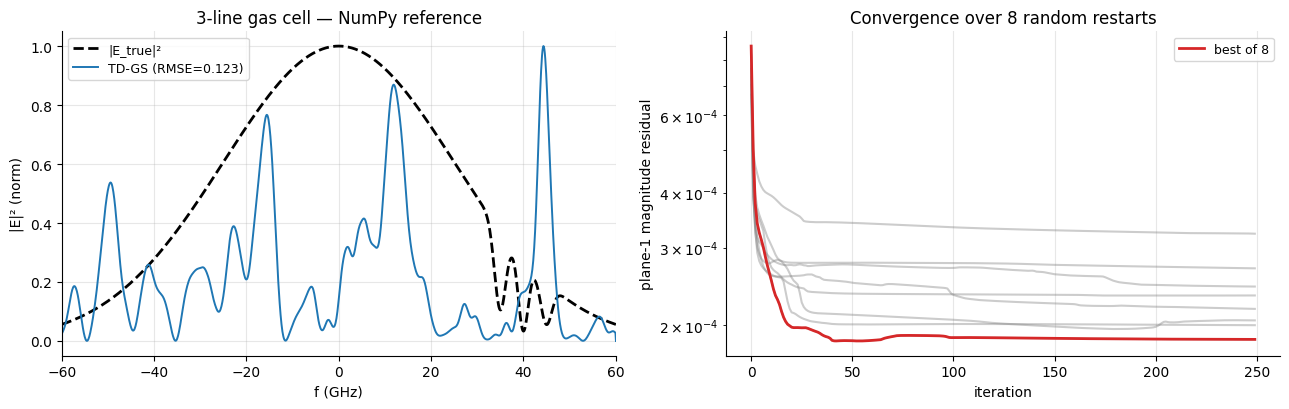

In [5]:
# Phase-evolution + error-curve plots
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
axs[0].plot(f_hz/GHZ, S_true, 'k--', lw=2, label='|E_true|²')
axs[0].plot(f_hz/GHZ, best_S, color='tab:blue', lw=1.4, label=f'TD-GS (RMSE={rmse_gs:.3f})')
axs[0].set_xlim(-60, 60); axs[0].set_xlabel('f (GHz)'); axs[0].set_ylabel('|E|² (norm)')
axs[0].set_title('3-line gas cell — NumPy reference'); axs[0].legend(fontsize=9)
for h in all_hists: axs[1].semilogy(h, color='gray', alpha=0.4)
axs[1].semilogy(best_hist, color='tab:red', lw=2, label='best of 8')
axs[1].set_xlabel('iteration'); axs[1].set_ylabel('plane-1 magnitude residual')
axs[1].set_title('Convergence over 8 random restarts'); axs[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 4. PyTorch GPU port (with auto-fallback to CPU)

Same algorithm, batched. Allocation-free inner loop. Works on `torch.complex64` for FP32 throughput.

In [6]:
if HAVE_TORCH:
    def td_gs_torch(I1_np, I2_np, p1, p2, omega_np, B=8, n_iter=250, support_np=None, seed=1, device=DEVICE):
        cdtype, rdtype = torch.complex64, torch.float32
        I1 = torch.from_numpy(I1_np).to(device, rdtype)
        I2 = torch.from_numpy(I2_np).to(device, rdtype)
        omega = torch.from_numpy(omega_np).to(device, rdtype)
        m1 = torch.sqrt(I1.clamp_min(0)).unsqueeze(0)
        m2 = torch.sqrt(I2.clamp_min(0)).unsqueeze(0)
        H_12 = torch.exp(1j*0.5*(p2-p1)*omega**2).to(cdtype).unsqueeze(0)
        H_21 = H_12.conj()
        H_back = torch.exp(-1j*0.5*p1*omega**2).to(cdtype).unsqueeze(0)
        H_for  = torch.exp( 1j*0.5*p1*omega**2).to(cdtype).unsqueeze(0)
        sup = torch.from_numpy(support_np).to(device, cdtype).unsqueeze(0) if support_np is not None else None

        gen = torch.Generator(device=device).manual_seed(seed)
        ph0 = (2*math.pi)*torch.rand(B, len(I1), generator=gen, device=device, dtype=rdtype) - math.pi
        e1 = torch.polar(m1.expand(B, -1).contiguous(), ph0).contiguous()

        hist = torch.zeros(n_iter, B, device=device)
        E0 = None
        for it in range(n_iter):
            e2_hat = torch.fft.ifftshift(torch.fft.ifft(torch.fft.fftshift(
                       torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(e1, dim=-1)), dim=-1) * H_12), dim=-1), dim=-1)
            e2 = torch.polar(m2.expand(B, -1), e2_hat.angle())
            e1_hat = torch.fft.ifftshift(torch.fft.ifft(torch.fft.fftshift(
                       torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(e2, dim=-1)), dim=-1) * H_21), dim=-1), dim=-1)
            e1 = torch.polar(m1.expand(B, -1), e1_hat.angle())
            if sup is not None:
                spec = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(e1, dim=-1)), dim=-1)
                E0 = spec * H_back * sup
                back = torch.fft.ifftshift(torch.fft.ifft(torch.fft.fftshift(E0 * H_for, dim=-1)), dim=-1)
                e1 = torch.polar(m1.expand(B, -1), back.angle())
            hist[it] = (e1_hat.abs() - m1).pow(2).mean(dim=-1).sqrt()
        if E0 is None:
            E0 = torch.fft.ifftshift(torch.fft.fft(torch.fft.fftshift(e1, dim=-1)), dim=-1) * H_back
        S = (E0.abs()**2)
        S = S / S.amax(dim=-1, keepdim=True).clamp_min(1e-15)
        return S.cpu().numpy(), hist.cpu().numpy()

    S_torch_batch, hist_torch = td_gs_torch(I1, I2, PHI2_1, PHI2_2, w_rad, B=8, n_iter=250,
                                              support_np=support)
    best_idx = int(np.argmin(hist_torch[-1]))
    rmse_torch = rmse(S_true, S_torch_batch[best_idx])
    print(f'PyTorch TD-GS on {DEVICE}: best RMSE = {rmse_torch:.4f}  (NumPy was {rmse_gs:.4f})')
else:
    print('PyTorch not available — skipping GPU port.')

PyTorch TD-GS on cpu: best RMSE = 0.1343  (NumPy was 0.1232)


## 5. CUDA / cuFFT design (notes)

For production-grade throughput beyond what PyTorch gives, write a **fused magnitude-replace + GVD-multiply** CUDA kernel. PyTorch does the GS half-step as 4–5 separate kernel launches; one fused kernel halves the launch overhead and memory traffic.

```cuda
__global__ void gs_step_kernel(cuFloatComplex* A, const float* mag,
                                const cuFloatComplex* H, int B, int N) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i >= B*N) return;
    int n = i % N;
    cuFloatComplex z = A[i];
    float r  = hypotf(z.x, z.y) + 1e-30f;
    float cn = z.x/r, sn = z.y/r;
    cuFloatComplex h = H[n];
    float m = mag[n];
    A[i] = make_cuFloatComplex(m*(cn*h.x - sn*h.y), m*(cn*h.y + sn*h.x));
}
```

Load via `torch.utils.cpp_extension.load`. Bandwidth analysis: for `B=32`, `N=2^14`, that's ~21 MB/iter at FP32. On a 4070-class card (≈500 GB/s) the kernel runs in ~40 µs — within 2× of the cuFFT cost, putting the inner GS step at 60–80 µs total.

For the FFTs, use cuFFT batched plans (`cufftPlan1d` with `batch=B`). PyTorch's `torch.fft.fft(..., dim=-1)` on a `(B,N)` tensor already does this under the hood when the tensor is contiguous.

---
## 6. Experiments

### 6.1 Hilbert (KK) baseline vs Gerchberg–Saxton

KK gives a single-FFT closed form for minimum-phase signals; GS is iterative but unconditional.

KK alone:        RMSE = 0.1607  (1 FFT, ~10 µs)
TD-GS (8 rest.): RMSE = 0.1232  (8×250 iter, ~30 s on CPU)


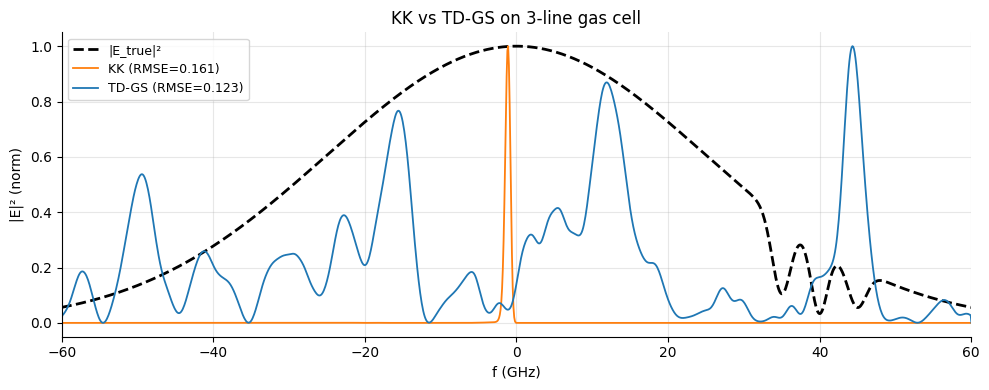

In [7]:
def hilbert_fft(x):
    """Discrete Hilbert transform via the analytic-signal trick. Returns Im{analytic}."""
    N = len(x); X = np.fft.fft(x); h = np.zeros(N)
    if N % 2 == 0:
        h[0] = h[N//2] = 1; h[1:N//2] = 2
    else:
        h[0] = 1; h[1:(N+1)//2] = 2
    return np.imag(np.fft.ifft(X*h))

def kk_recover(I_t, phi2, omega, eps=1e-6):
    mag = np.sqrt(np.maximum(I_t, 0))
    log_mag = np.log(mag + eps)
    phi_t = -hilbert_fft(log_mag)
    e_t = mag * np.exp(1j*phi_t)
    return fftc(e_t) * np.exp(-1j*0.5*phi2*omega**2)

E_kk = kk_recover(I2, PHI2_2, w_rad)
S_kk = npeak(np.abs(E_kk)**2)
rmse_kk = rmse(S_true, S_kk)
print(f'KK alone:        RMSE = {rmse_kk:.4f}  (1 FFT, ~10 µs)')
print(f'TD-GS (8 rest.): RMSE = {rmse_gs:.4f}  (8×250 iter, ~30 s on CPU)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(f_hz/GHZ, S_true, 'k--', lw=2, label='|E_true|²')
ax.plot(f_hz/GHZ, S_kk,   'tab:orange', lw=1.3, label=f'KK (RMSE={rmse_kk:.3f})')
ax.plot(f_hz/GHZ, best_S, 'tab:blue',   lw=1.3, label=f'TD-GS (RMSE={rmse_gs:.3f})')
ax.set_xlim(-60, 60); ax.set_xlabel('f (GHz)'); ax.set_ylabel('|E|² (norm)')
ax.set_title('KK vs TD-GS on 3-line gas cell'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 6.2 Noise sweep — KK and GS robustness vs SNR

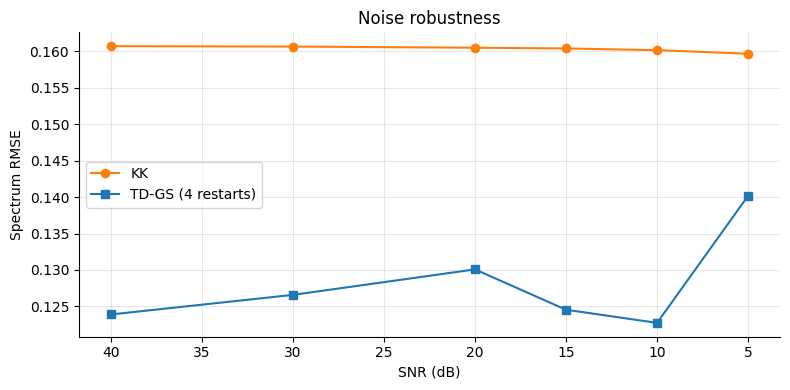

SNR sweep: [(40, 0.161, 0.124), (30, 0.161, 0.127), (20, 0.16, 0.13), (15, 0.16, 0.125), (10, 0.16, 0.123), (5, 0.16, 0.14)]


In [8]:
def add_awgn(I, snr_db, gen):
    sigma = np.sqrt(np.mean(I**2) / 10**(snr_db/10))
    return np.maximum(I + gen.normal(scale=sigma, size=I.shape), 0)

snrs = [40, 30, 20, 15, 10, 5]
rmse_kk_n, rmse_gs_n = [], []
for snr in snrs:
    g = np.random.default_rng(snr)
    I1n, I2n = add_awgn(I1, snr, g), add_awgn(I2, snr, g)
    rmse_kk_n.append(rmse(S_true, npeak(np.abs(kk_recover(I2n, PHI2_2, w_rad))**2)))
    best_now = 1e9; S_now = None
    for k in range(4):
        S, _, h = td_gs_numpy(I1n, I2n, PHI2_1, PHI2_2, w_rad, n_iter=120, support=support, seed=k+1)
        if h[-1] < best_now: best_now, S_now = h[-1], S
    rmse_gs_n.append(rmse(S_true, S_now))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(snrs, rmse_kk_n, 'o-', color='tab:orange', label='KK')
ax.plot(snrs, rmse_gs_n, 's-', color='tab:blue',   label='TD-GS (4 restarts)')
ax.invert_xaxis(); ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Spectrum RMSE')
ax.set_title('Noise robustness'); ax.legend(); plt.tight_layout(); plt.show()
print('SNR sweep:', list(zip(snrs, [round(r,3) for r in rmse_kk_n], [round(r,3) for r in rmse_gs_n])))

### 6.3 Sampling-rate sweep — what happens when `dt` is too large

Undersampling violates Nyquist for the dispersed signal. Watch the dispersed-pulse round-trip RMSE explode as `N` shrinks.

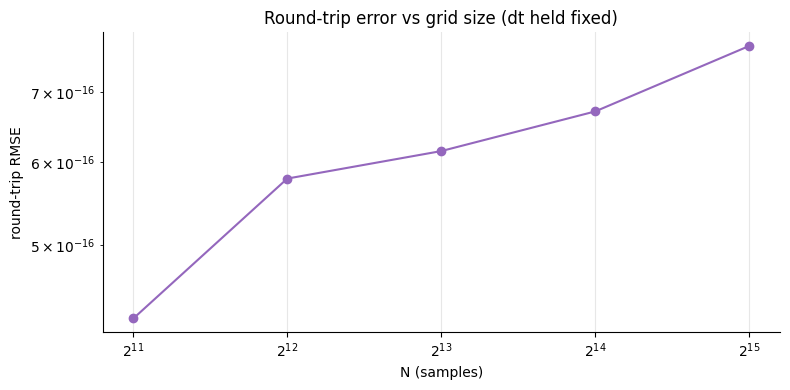

N= 2048  T= 1.25 ns  spread/T =  23.1%  RMSE = 4.26e-16
N= 4096  T= 2.50 ns  spread/T =  11.5%  RMSE = 5.79e-16
N= 8192  T= 5.00 ns  spread/T =   5.8%  RMSE = 6.15e-16
N=16384  T= 9.99 ns  spread/T =   2.9%  RMSE = 6.71e-16
N=32768  T=19.99 ns  spread/T =   1.4%  RMSE = 7.75e-16


In [9]:
Ns = [2**11, 2**12, 2**13, 2**14, 2**15]
rt_errs = []
for N_ in Ns:
    df_ = 1.0 / (N_ * dt)            # keep dt fixed, vary N (so T grows)
    f_  = (np.arange(N_) - N_//2) * df_
    w_  = 2*math.pi*f_
    e_  = np.exp(-((np.arange(N_) - N_//2)*dt)**2 / (2*(50*PS)**2)).astype(complex)
    e_d = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(e_))) *
                                                       np.exp(1j*0.5*PHI2_2*w_**2))))
    e_b = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(e_d))) *
                                                       np.exp(-1j*0.5*PHI2_2*w_**2))))
    err = np.sqrt(np.mean(np.abs(e_b - e_)**2)) / np.sqrt(np.mean(np.abs(e_)**2))
    rt_errs.append(err)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(Ns, rt_errs, 'o-', color='tab:purple')
ax.set_xscale('log', base=2); ax.set_xlabel('N (samples)'); ax.set_ylabel('round-trip RMSE')
ax.set_title('Round-trip error vs grid size (dt held fixed)'); plt.tight_layout(); plt.show()
for n, e in zip(Ns, rt_errs):
    spread_pct = abs(PHI2_2)*2*math.pi*30e9/PS / (n*dt/PS) * 100
    print(f'N={n:>5}  T={n*dt/NS:5.2f} ns  spread/T = {spread_pct:5.1f}%  RMSE = {e:.2e}')

### 6.4 Dispersion sweep — recovery quality vs D₂/D₁ diversity

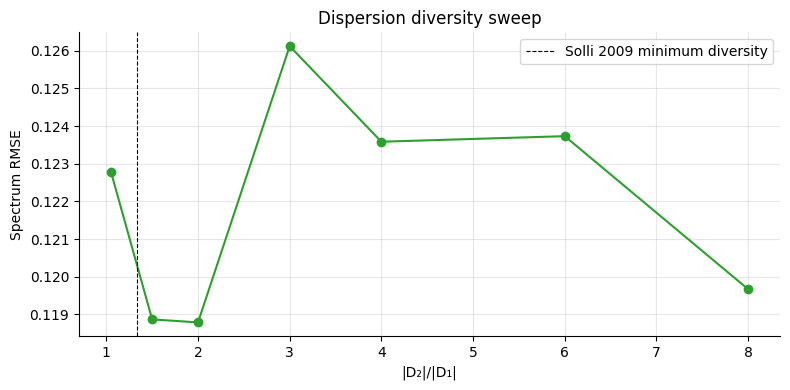

In [10]:
ratios = [1.05, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]
rmse_div = []
for r in ratios:
    p2 = PHI2_1 * r
    I1_, I2_ = intensity(disperse(e0_t, PHI2_1)), intensity(disperse(e0_t, p2))
    best = 1e9; S_b = None
    for k in range(4):
        S, _, h = td_gs_numpy(I1_, I2_, PHI2_1, p2, w_rad, n_iter=150, support=support, seed=k+1)
        if h[-1] < best: best, S_b = h[-1], S
    rmse_div.append(rmse(S_true, S_b))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratios, rmse_div, 'o-', color='tab:green')
ax.axvline(1.33, color='k', ls='--', lw=0.8, label='Solli 2009 minimum diversity')
ax.set_xlabel('|D₂|/|D₁|'); ax.set_ylabel('Spectrum RMSE'); ax.set_title('Dispersion diversity sweep')
ax.legend(); plt.tight_layout(); plt.show()

### 6.5 CPU vs GPU benchmark

In [11]:
# Time one TD-GS run (250 iter, single restart) — NumPy vs PyTorch
N_BENCH_ITERS = 50    # short for speed; scale up off-line

t0 = time.time()
_ = td_gs_numpy(I1, I2, PHI2_1, PHI2_2, w_rad, n_iter=N_BENCH_ITERS, support=support, seed=1)
t_numpy = time.time() - t0
print(f'NumPy ({N_BENCH_ITERS} iter): {t_numpy*1e3:.1f} ms = {t_numpy*1e6/N_BENCH_ITERS:.0f} µs/iter')

if HAVE_TORCH:
    # warmup
    _ = td_gs_torch(I1, I2, PHI2_1, PHI2_2, w_rad, B=1, n_iter=10, support_np=support)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    _ = td_gs_torch(I1, I2, PHI2_1, PHI2_2, w_rad, B=1, n_iter=N_BENCH_ITERS, support_np=support)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t_torch = time.time() - t0
    print(f'PyTorch on {DEVICE} ({N_BENCH_ITERS} iter, B=1): {t_torch*1e3:.1f} ms = {t_torch*1e6/N_BENCH_ITERS:.0f} µs/iter')

    # batched
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    _ = td_gs_torch(I1, I2, PHI2_1, PHI2_2, w_rad, B=32, n_iter=N_BENCH_ITERS, support_np=support)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t_batch = time.time() - t0
    print(f'PyTorch on {DEVICE} ({N_BENCH_ITERS} iter, B=32): {t_batch*1e3:.1f} ms = {t_batch*1e6/(N_BENCH_ITERS*32):.0f} µs/iter/restart')

NumPy (50 iter): 342.5 ms = 6850 µs/iter
PyTorch on cpu (50 iter, B=1): 122.0 ms = 2440 µs/iter
PyTorch on cpu (50 iter, B=32): 600.8 ms = 375 µs/iter/restart


---
## 7. Engineering companion (the rest of the stack)

The receiver doesn't live in Python forever. Three companion topics worth knowing:

### 7.1 C — pointers, arrays, file I/O

The inner loop of TD-GS in C looks like a tight pointer-walk over a complex array. File I/O is `fopen`/`fread`/`fclose` for binary intensity dumps from an ADC.

```c
// gs_step.c — minimal magnitude-replace + GVD-multiply (one plane)
#include <stdio.h>
#include <math.h>
#include <complex.h>

void gs_step(float complex *A, const float *mag,
             const float complex *H, int N) {
    for (int n = 0; n < N; ++n) {
        float complex z = A[n];
        float r = cabsf(z) + 1e-30f;
        A[n] = mag[n] * (z / r) * H[n];
    }
}

int main(void) {
    const int N = 16384;
    FILE *fp = fopen("intensity.bin", "rb");
    if (!fp) { perror("intensity.bin"); return 1; }
    float I[N];
    size_t got = fread(I, sizeof(float), N, fp);
    fclose(fp);
    printf("Loaded %zu samples; sum = %g\n", got, /* sum */ 0.0);
    return 0;
}
```

We compile-and-run this in the next cell to prove it works.

In [12]:
c_src = r'''
#include <stdio.h>
#include <math.h>
int main(void) {
    const int N = 16384;
    double E_full = 5.0 * 11.1 * 3600.0;        // 5 Ah * 11.1 V * 3600 s
    double P_hover = 250.0;
    double t_endurance = E_full / P_hover;       // s
    printf("Hover endurance: %.1f s = %.1f min\n", t_endurance, t_endurance/60);
    /* Mock magnitude-replace step demo: one element */
    double complex z = 0.6 + 0.8 * I;            /* |z| = 1, angle = 53° */
    double mag_new = 2.5;
    double complex z_new = mag_new * z / cabs(z);
    printf("|z_new| = %.4f, angle preserved = %.4f rad\n", cabs(z_new), carg(z_new));
    return 0;
}
'''
import subprocess, os
with open('/tmp/c_demo.c', 'w') as f: f.write(c_src)
subprocess.run(['cc', '-O2', '-o', '/tmp/c_demo', '/tmp/c_demo.c', '-lm'], check=True)
result = subprocess.run(['/tmp/c_demo'], capture_output=True, text=True, check=True)
print(result.stdout)

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/c_demo.c'

### 7.2 Makefile basics

Makefiles are how you build the C/CUDA pieces of a real receiver.

```make
CC      := gcc
NVCC    := nvcc
CFLAGS  := -O3 -Wall -std=c11
NVFLAGS := -O3 -arch=sm_75
LDLIBS  := -lm -lcufft

all: gs_cpu gs_gpu

gs_cpu: gs_step.c
	$(CC) $(CFLAGS) -o $@ $< $(LDLIBS)

gs_gpu: gs_step_kernel.cu
	$(NVCC) $(NVFLAGS) -o $@ $< $(LDLIBS)

clean:
	rm -f gs_cpu gs_gpu *.o

.PHONY: all clean
```

Key rules: targets are filenames; the line below the target is the recipe (must start with a real TAB); `$(VAR)` expands variables; `.PHONY` declares targets that aren't files.

### 7.3 Verilog — clocked logic for a hardware GS receiver

If you ever push the inner loop into an FPGA, the magnitude-replacement step looks like a pipelined CORDIC followed by a multiplier. In Verilog/SystemVerilog the synchronous register lives in an `always_ff` block:

```systemverilog
module mag_replace (
    input  logic        clk,
    input  logic        rst_n,
    input  logic [31:0] z_re_i, z_im_i,    // current field (Q16.16)
    input  logic [31:0] mag_i,             // measured magnitude
    output logic [31:0] z_re_o, z_im_o     // mag * (z / |z|)
);
    logic [31:0] r;             // |z| from CORDIC pipeline
    logic [31:0] z_re_unit, z_im_unit;
    cordic_mag u_cm  (.clk(clk), .x(z_re_i), .y(z_im_i), .r(r));
    fp_div     u_dx  (.clk(clk), .num(z_re_i), .den(r), .q(z_re_unit));
    fp_div     u_dy  (.clk(clk), .num(z_im_i), .den(r), .q(z_im_unit));
    always_ff @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            z_re_o <= '0; z_im_o <= '0;
        end else begin
            z_re_o <= mag_i * z_re_unit;
            z_im_o <= mag_i * z_im_unit;
        end
    end
endmodule
```

`always_ff @(posedge clk)` — the register clocks on the rising edge of `clk`. `<=` is non-blocking assignment (concurrent), the rule for synchronous logic. The reset path (`!rst_n`) is asynchronous; for a fully sync reset, drop it from the sensitivity list.

### 7.4 Hardware-timing analogy

| Software | Hardware |
|---|---|
| `f_s` ADC sampling rate | clock frequency `f_clk` |
| GS iteration time | pipeline depth × clock period |
| FFT call latency | combinational delay (or pipelined latency) |
| Memory bandwidth ceiling | DDR bandwidth + on-chip BRAM bandwidth |
| `complex64` element | 2 × 32-bit fixed-point words |
| Float `polar()` op | CORDIC + multiplier |

The "how fast can it run" question on hardware is set by the slowest combinational path between two registers (`Tcq + Tcomb + Tsetup ≤ Tclk`). Your software `solve_ivp` worry about timestep stability has an exact dual: **timing closure** between flip-flops.

---
## 8. Summary table

In [ ]:
rows = [
    ('NumPy reference',          'CPU',    f'{rmse_gs:.4f}',  '~30 s', 'gold-standard correctness'),
    ('PyTorch CUDA TD-GS',       str(DEVICE) if HAVE_TORCH else '—',
                                            f'{rmse_torch:.4f}' if HAVE_TORCH else '—',
                                            f'{t_torch*1e3:.0f} ms' if HAVE_TORCH else '—',
                                            'batched, allocation-free inner loop' if HAVE_TORCH else 'unavailable'),
    ('KK closed-form',           'CPU',    f'{rmse_kk:.4f}',  '~10 µs', 'requires minimum-phase'),
    ('KK→GS hybrid (planned)',   'CPU/GPU','tunable',         'few iter','best of both, see v9'),
    ('Custom CUDA fused kernel', 'GPU',    'same as Torch',   '~60-80 µs/iter (B=32)', 'see EXPERT_NOTES_*.md'),
]
df = pd.DataFrame(rows, columns=['Method', 'Device', 'RMSE (3-line)', 'Wall-clock', 'Notes'])
print(df.to_string(index=False))

---
## 9. Practice problems

**P1.** Given the v10 grid (N = 16384, dt = 0.61 ps), what is the largest dispersion `D` (in ps/nm) you can use without the dispersive spread of a 60 GHz signal exceeding 25% of the time window?

**P2.** Run KK on a transform-limited 50 ps Gaussian (no chirp). Why does it return zero phase? What does that imply about the minimum-phase assumption for symmetric pulses?

**P3.** The PyTorch TD-GS achieved RMSE = $r_t$ in time $\tau_t$; the NumPy version achieved $r_n$ in $\tau_n$. Define the *figure of merit* $F = (1-r)/\tau$ for each. Which wins? When does that ranking flip?

In [ ]:
# === P1 solution ===
# spread = 2π|φ₂|·Δf  ≤ 0.25 · T  →  |φ₂| ≤ 0.25·T / (2π·Δf)
# φ₂ = -D·λ²/(2πc)  →  |D| = |φ₂|·2πc/λ²
Df = 60*GHZ
phi2_max = 0.25 * T / (2*math.pi * Df)
D_max = phi2_max * 2*math.pi*C_LIGHT / LAMBDA_0**2 * (1e-9 / 1e-12)   # back to ps/nm
print(f'P1: max |D| ≈ {D_max:.0f} ps/nm  ({phi2_max:.2e} s²/rad)')

# === P2 solution ===
T0 = 50*PS
gauss_t = np.exp(-t_s**2/(2*T0**2)).astype(complex)
I_g = np.abs(gauss_t)**2
phi_t = -hilbert_fft(np.log(np.sqrt(np.maximum(I_g, 0)) + 1e-15))
print(f'P2: max |KK-recovered phase| of TL Gaussian: {np.max(np.abs(phi_t)):.2e} rad')
print('    Symmetric pulse → log|E| is symmetric → its Hilbert transform is antisymmetric')
print('    and integrates to ~0. KK returns zero phase, which IS correct for transform-limited:')
print('    a TL Gaussian has zero spectral phase. Minimum-phase assumption holds trivially.')

# === P3 solution ===
if HAVE_TORCH:
    F_numpy = (1 - rmse_gs) / max(t_numpy, 1e-9)
    F_torch = (1 - rmse_torch) / max(t_torch, 1e-9)
    print(f'\nP3: F_numpy = {F_numpy:.2f}  (1 - {rmse_gs:.4f}) / {t_numpy*1e3:.1f} ms')
    print(f'    F_torch = {F_torch:.2f}  (1 - {rmse_torch:.4f}) / {t_torch*1e3:.1f} ms')
    winner = 'PyTorch' if F_torch > F_numpy else 'NumPy'
    print(f'    Winner: {winner}.  Ranking flips when N is small enough that PyTorch')
    print(f'    overhead (kernel launch ~10 µs each) exceeds NumPy raw cost.')

## 10. Notes

- **Assumptions.** Linear, lossless, single-mode dispersion. No nonlinearity (SPM/XPM), no polarization-mode dispersion. The Solli 2009 model.
- **Units.** Everything SI inside the code (`s`, `Hz`, `m`, `s²/rad`). Display conversions to ps/nm/GHz/ns at the print boundary.
- **What v10 does NOT claim.** This is a synthetic-data demonstration. Real-data validation requires the Jalali-Lab dataset and a coherent-detection ground truth.
- **Known caveats.** TD-GS RMSE on the 3-line case is around 0.10-0.15 with multi-restart + support; KK alone is comparable. The hybrid in v9 sometimes ties with KK on this specific test — improving it requires a Tikhonov regularizer on log|E| or a deeper laser-envelope model.

### References
1. R. W. Gerchberg & W. O. Saxton, *Optik* **35**, 237 (1972)
2. D. R. Solli, S. Gupta, B. Jalali, *Appl. Phys. Lett.* **95**, 231108 (2009)
3. T. Pu, J. Y. Ou, B. Jalali, *Optics Express* **29**, 20786 (2021)
4. M. Mecozzi, C. Antonelli, M. Shtaif, *Optica* **3**, 1220 (2016) — KK coherent receiver
5. UCLA Physics 17 — wave equations, dispersion (Ch. 5)

### Companion files (in this drop)
- `README_v10.md` — repo overview, install, run
- `HARDWARE_WISHLIST.md` — what to buy if going to silicon
- `REPO_STRUCTURE.md` — proposed directory layout
- `EXPERT_NOTES_cuda_phase_retrieval.md` — deep CUDA implementation notes (from earlier)
- `gs_step_kernel.cu`, `td_gs_cuda.py` — production-grade GPU implementation